# Assignment: Linear Models
## Do three questions.
### `! git clone https://github.com/ds4e/linearModels`

**Q1.** Please answer the following questions in your own words.

1. ~~What makes a model "linear"? "Linear" in what?~~
   - A linear model maps a *linear relationship* between variables in our feature space and our target variable.
   - We can use the relationship to predict outcomes when given *new* data. 
   - They utilise the equation y=mx+b as their basis.
      - Single linear regression (lin reg using only one variable) may use this equation, and this equation alone. 
      - Multiple linear regression adjusts this equation to account for how multiple predictors influence our target variable; sometimes, the equation is modified to account for non-linear interactions between variables.
      - Transformations of variables do not make the model non-linear; it just adjusts the values for our variable. 
2. ~~How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.)~~
   - The intercept of our model represents the proportion of 1's in our dummy variable column that match our target outcome minus the proportion of 0's in our dummy variable column that match said target outcome. 
4. ~~Can linear regression be used for classification? Explain why, or why not.~~
   - Linear regressions cannot be used for classification because they predict numeric values, not categorical values, so they are unable to take a datapoint with certain features and fit it into a qualitative "box," so to speak. Theoretically if you try hard enough maybe but it's a terrible idea in all honesty. You're better off using k-NN or k-MC. 
6. ~~What are signs that your linear model is over-fitting?~~
  - We can tell our linear model is overfit when its root mean squared error (or any other error metric we are trying to minimise) begins increasing after we've seen it decrease.
  - A model may overfit when we add too many variables to the feature space.
  - When a model overfits, it comes to represent small parts of the data that are irrepresentative of the data overall. 
5. ~~Clearly explain multi-colinearity using the two-stage least squares technique.~~ **(MY SOURCE FOR THIS: IBM, PENN STATE)**
*Using the two-stage least squares technique...*
  -  Independent variables are sometimes correlated with one another. Using correlated variables in your model may sway the model strongly in one direction and will lead it to not make very useful predictions, so you would want to get rid of them.
  -  Two stage least squares regression ensures that independent variables do not affect one another. 
  -  We might compute a 'proxy' for the problematic variable causing multiple colinearity using another variable and a transformed version of the problematic variable. 
  -  Then, the new, computed variable replaces the old problematic variable. 
6. ~~How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?~~
  - We can include transformations of our independent variables 'x' into our model. The transformations do NOT cause the model to become nonlinear; it simply changes the values in our feature matrix. We can establish a linear relationship between the *new* values in the feature matrix and our target variable 'y'. 
7. ~~What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?~~
  - In Q4, question 2, we can see that intercept is the slope coefficient for our *treatment effect*, which was calculated with (mean of dummy variable colum 2) - (mean of dummy variable column 1) 

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighbourhood `; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood `.
2. Regress price on `Neighbourhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model and using all the data. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighbourhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multilple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly scaled variables that require a log or arcsinh transformation). Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: `control` for not receiving a transplant and `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. ~~Compute (a) the proportion of people who survive in the control group who do not receive a transplant, and (b) the difference between the proportion of people who survive in the treatment group and the proportion of people who survive in the control group. In a randomized controlled trial, this is called the **average treatment effect**.~~
2. ~~Regress `y` on `transplant` using a linear model with a constant. How does the constant/intercept of the regression and the coefficient on transplant compare to your answers from part 1? Explain the relationship clearly.~~
3. ~~We'd like to include `age` in the regression, since it's reasonable to expect that older patients are less likely to survive an extensive surgery like a heart transplant. Regress `y` on a constant, transplant, and age. How does the intercept change?~~
4. ~~Build a more flexible model that allows for non-linear age effects and interactions between age and treatment. Use a train-test split to validate your model.~~ ~~Estimate your best model~~, predict the survival probability by age, and plot your results conditional on receiving a transplant and not. Describe what you see.
5. ~~Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?~~

### question one

In [1]:
# importing dependencies
import pandas as pd 

/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


In [2]:
# importing dataset 
heart_data = pd.read_csv("./data/heart_hw.csv") 
heart_data.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [3]:
# what's the name of the non-control group?
heart_data["transplant"].value_counts()
# 'treatment'

transplant
treatment    69
control      34
Name: count, dtype: int64

In [4]:
# splitting up the data into control and treatment data
control_only = heart_data.where(heart_data["transplant"] == "control").dropna()
treatment_only = heart_data.where(heart_data["transplant"] == "treatment").dropna()
print(control_only.head())
print(treatment_only.head())

   Unnamed: 0   age transplant    y
0         1.0  53.0    control  0.0
1         2.0  43.0    control  0.0
2         3.0  52.0    control  0.0
3         4.0  52.0    control  0.0
4         5.0  54.0    control  0.0
    Unnamed: 0   age transplant    y
7          8.0  41.0  treatment  0.0
15        16.0  40.0  treatment  0.0
17        18.0  54.0  treatment  0.0
18        19.0  29.0  treatment  0.0
22        23.0  55.0  treatment  0.0


In [5]:
# a) who survives? 
survive_c = control_only.where(control_only["y"] == 1).dropna()
survive_t = treatment_only.where(treatment_only["y"] == 1).dropna()
p_survive_c = len(survive_c) / len(control_only)
p_survive_t = len(survive_t) / len(treatment_only)
print(p_survive_c) 
print(p_survive_t - p_survive_c)

0.11764705882352941
0.23017902813299232


### question two

In [6]:
# using a linear model with a constant, so y=mx+b styled. 

# import a dependency. 
import numpy as np 

# slr function from our codebook. 
def slr(x,y): 
    """ Single linear regression function. """
    x_bar = np.mean(x)
    y_bar = np.mean(y)
    b1 = np.inner(x-x_bar,y-y_bar)/np.inner(x-x_bar,x)
    b0 = y_bar - b1*x_bar
    y_hat = b0 + b1*x
    residuals = y - y_hat
    return({'b0':b0,'b1':b1,'y_hat':y_hat,'residuals':residuals})

In [7]:
# because our 'transplant' variable is categorical, we wanna one-hot-encode it.

# importing dependencies
from sklearn.preprocessing import OneHotEncoder

In [8]:
# one hot encoding process
heart_data_transplant = pd.DataFrame([])
heart_data_transplant["transplant"] = pd.DataFrame(heart_data["transplant"])
# using one hot encoder tool 
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(heart_data_transplant)
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(["transplant"]))

In [9]:
# did it work? 
one_hot_df.head()

,transplant_control,transplant_treatment
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0


In [10]:
# cheeky little x and y split 
X = one_hot_df[["transplant_control", "transplant_treatment"]]
y = heart_data["y"]

In [11]:
# importing dependencies for regression 
from sklearn.linear_model import LinearRegression

In [12]:
# fitting the model
reg = LinearRegression().fit(X, y) 
print(reg.intercept_) # intercept
print(reg.coef_) # coefficient
print(reg.score(X, y)) # rsq

0.2327365728900255
[-0.11508951  0.11508951]
0.059188892948483174


- My intercept is equal to the proportion of treatment group survivors minus the proportion of control group survivors.
- My regression coefficients are always equal to the absolute value of the proportion of control group survivors. 

### question three

In [13]:
# adding to our feature matrix 
X_1 = one_hot_df.join(heart_data["age"])

In [14]:
# putting this in a separate code chunk because i dont wanna rerun things
# adding constant value, and then viewing the dataframe
X_1["constant"] = 1
X_1.head()
# (remember, = is an assignment operator, == is a comparison operator) 

,transplant_control,transplant_treatment,age,constant
0,1.0,0.0,53,1
1,1.0,0.0,43,1
2,1.0,0.0,52,1
3,1.0,0.0,52,1
4,1.0,0.0,54,1


In [15]:
# fitting the model
reg = LinearRegression().fit(X_1, y) 
print(reg.intercept_) # intercept
print(reg.coef_) # coefficient
print(reg.score(X_1, y)) # rsq

0.834307815425931
[-0.13235084  0.13235084 -0.01360722  0.        ]
0.1467806594163431


- When I add "age" to my linear regression model, the intercept increases.
- The absolute value of the slope increases; in other words, the correlation coefficient demonstrates a *slightly* stronger negative correlation. (Age is only slightly correlated with death.) 
- The absolute value of the "age" coefficient is added to the absolute value of the coefficients I had when I regressed on `transplant_control` and `transplant_treatment`.

### question four

In [16]:
# import dependencies for plotting
import matplotlib.pyplot as plt

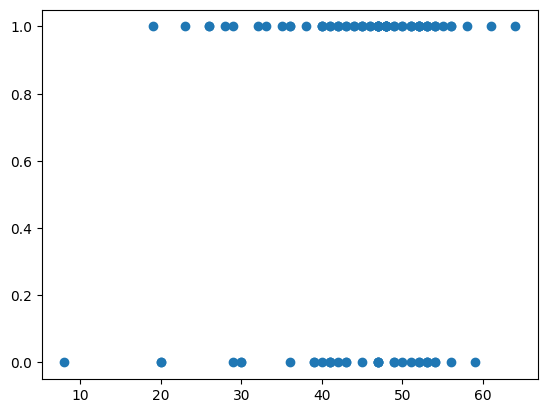

In [17]:
# how exactly do age and treatment interact? 
plt.scatter(X_1["age"], X_1["transplant_treatment"])

In [18]:
# that doesnt help us 
# oh well, instead of trying to do specific things, we might want to just...
# ...square values because of our time constraints. 
# importing dependencies 
from sklearn.preprocessing import PolynomialFeatures

In [19]:
# squaring things 
# code from class workbook 
X_A = X_1.drop(columns=["constant"])
expander = PolynomialFeatures(degree=2,include_bias=False)
Z = expander.fit_transform(X_A) # Pass the df into the expander to get powers/interactions of x and y
names = expander.get_feature_names_out() # Get the names of these variables
zdf = pd.DataFrame(data=Z, columns = names) # Create a new, expanded dataframe

# the instructions did not ask for anything but making a more flexible model, 
# so i won't go past degree 2. 
zdf_1 = zdf.join(X_1["constant"])
zdf_1.head()

,transplant_control,transplant_treatment,age,transplant_control^2,transplant_control transplant_treatment,transplant_control age,transplant_treatment^2,transplant_treatment age,age^2,constant
0,1.0,0.0,53.0,1.0,0.0,53.0,0.0,0.0,2809.0,1
1,1.0,0.0,43.0,1.0,0.0,43.0,0.0,0.0,1849.0,1
2,1.0,0.0,52.0,1.0,0.0,52.0,0.0,0.0,2704.0,1
3,1.0,0.0,52.0,1.0,0.0,52.0,0.0,0.0,2704.0,1
4,1.0,0.0,54.0,1.0,0.0,54.0,0.0,0.0,2916.0,1


In [20]:
# train test splitting

# importing dependencies
from sklearn.model_selection import train_test_split

In [21]:
# the actual splitting
X_1_train, X_1_test, y_train, y_test = train_test_split(zdf_1, y, test_size=0.2, random_state=42)
# surveying some of the data
X_1_train.head()

,transplant_control,transplant_treatment,age,transplant_control^2,transplant_control transplant_treatment,transplant_control age,transplant_treatment^2,transplant_treatment age,age^2,constant
53,0.0,1.0,48.0,0.0,0.0,0.0,1.0,48.0,2304.0,1
22,0.0,1.0,55.0,0.0,0.0,0.0,1.0,55.0,3025.0,1
68,0.0,1.0,48.0,0.0,0.0,0.0,1.0,48.0,2304.0,1
44,0.0,1.0,53.0,0.0,0.0,0.0,1.0,53.0,2809.0,1
98,1.0,0.0,30.0,1.0,0.0,30.0,0.0,0.0,900.0,1


In [22]:
# model estimation
reg = LinearRegression().fit(X_1_train, y_train)
print(reg.intercept_) # Intercept value
print(reg.coef_) # Regression coefficients
print(reg.score(X_1_train, y_train)) # R squared measure

0.4505665051578469
[-0.18468075  0.18468075  0.00426427 -0.18468075  0.          0.00821174
  0.18468075 -0.00394748 -0.00024541  0.        ]
0.15618479650026795


In [23]:
# preparing for multiple linear regression 
# saving intercept, coefficients, and rsq in case we need them 
b0 = reg.intercept_ 
b1 = reg.coef_
rsq = reg.score(X_1_train, y_train)

In [24]:
# scikit can help us even more, according to geeks4geeks
from sklearn import linear_model, metrics

In [25]:
## code ''''''inspired'''''' by g4g - evaluating model performance - ##
# regression coefficients
print('Coefficients: ', reg.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg.score(X_1_test, y_test)))

Coefficients:  [-0.18468075  0.18468075  0.00426427 -0.18468075  0.          0.00821174
  0.18468075 -0.00394748 -0.00024541  0.        ]
Variance score: 0.23291360740208578


In [26]:
# that's an awful variance score, so i wonder if we're overfitting.
# let's see if we can drop some of our columns 
X_2_train = X_1_train.drop(columns=["transplant_control^2", "transplant_treatment^2", "age^2"], axis=1)

In [27]:
# we can also remove the thing that's gonna be zero x zero anyways lol 
X_2_train = X_2_train.drop(columns="transplant_control transplant_treatment", axis=1)

In [28]:
# same treatment for our test data
X_2_test = X_1_test.drop(columns=["transplant_control^2", "transplant_treatment^2", "age^2", "transplant_control transplant_treatment"], axis=1)

In [29]:
# let's try again 
# model estimation
reg_1 = LinearRegression().fit(X_2_train, y_train)
print(reg_1.intercept_) # Intercept value
print(reg_1.coef_) # Regression coefficients
print(reg_1.score(X_2_train, y_train)) # R squared measure

0.7741226825827869
[-0.43206288  0.43206288 -0.00818513  0.00338919 -0.01157432  0.        ]
0.1503730407396977


In [30]:
# regression coefficients
print('Coefficients: ', reg_1.coef_)

# variance score: 1 means perfect prediction
print('Variance score: {}'.format(reg_1.score(X_2_test, y_test)))

Coefficients:  [-0.43206288  0.43206288 -0.00818513  0.00338919 -0.01157432  0.        ]
Variance score: 0.19814573163787974


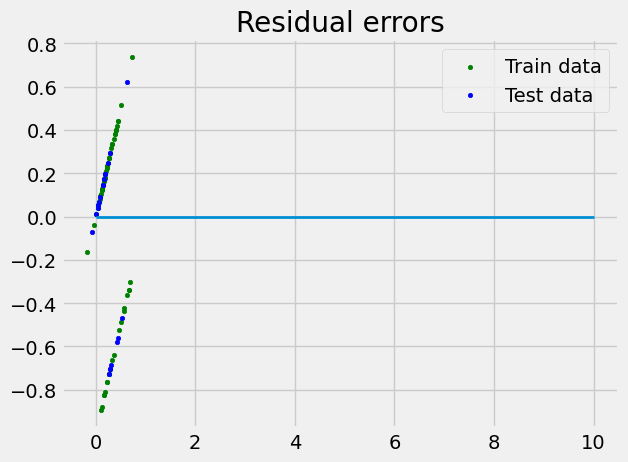

In [31]:
# i made it worse so i lost hope. 
# plot for residual error for our original 
# (code form geeksforgeeks) 

# setting plot style
plt.style.use('fivethirtyeight')

# plotting residual errors in training data
plt.scatter(reg.predict(X_1_train),
            reg.predict(X_1_train) - y_train,
            color="green", s=10,
            label='Train data')

# plotting residual errors in test data
plt.scatter(reg.predict(X_1_test),
            reg.predict(X_1_test) - y_test,
            color="blue", s=10,
            label='Test data')

# plotting line for zero residual error
plt.hlines(y=0, xmin=0, xmax=10, linewidth=2)

# plotting legend
plt.legend(loc='upper right')

# plot title
plt.title("Residual errors")

# method call for showing the plot
plt.show()

# it's a very poorly fit model 

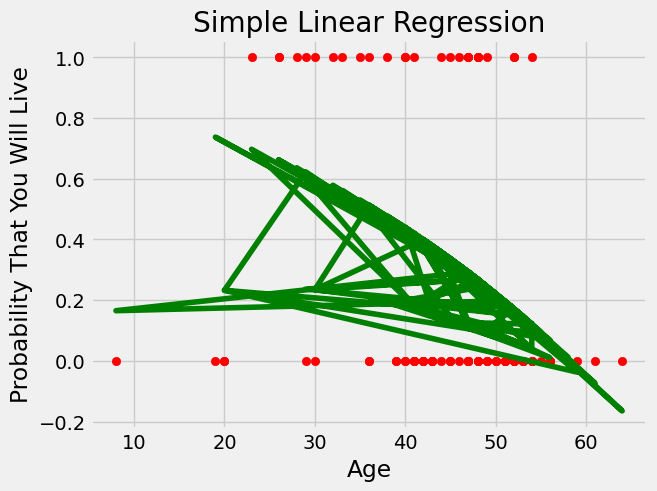

In [32]:
# plotting our results 
plt.scatter(zdf_1["age"],y,color='red')
plt.plot(zdf_1["age"],reg.predict(zdf_1),color='green')
plt.title('Simple Linear Regression')
plt.xlabel('Age')
plt.ylabel('Probability That You Will Live')
plt.show()

For both the treatment and the control groups, older patients are less likely to live. 

But that's most certainly not a linear line, so I will have to come to office hours to confront my mistakes. 

### question five

*"Imagine someone suggests using these kinds of models to select who receives organ transplants; perhaps the CDC or NIH starts using a scoring algorithm to decide who is contacted about a potential organ. What are your concerns about how it is built and how it is deployed?"*

I'm always worried about a linear model such as the one used here misjudging the situation of an individual, especially with how poorly fit my own model was. Not only am I concerned about the model making predictions based off of biased data (which I do not feel qualified to detect, as a non-medical-professional), but I am also concerned that *not* talking to a patient or their family about their particular situation would deprive the decision-making process of crucial data that an algorithm cannot *really* make decisions with. There are also very sticky ethical questions with very subjective answers with regards to choosing who gets to live or who gets to die; for example, we'd have to ask ourselves whether a single parent responsible for four children or a person who had been waiting on the transplant for longer is more "deserving" of receiving treatment. 

At the same time—with regards to health outcomes specifically—I do know that there is evidence that artificial intelligence is (sometimes) better at making diagnoses than even their human counterparts; however, as far as I'm aware, such accurate diagnoses are made with image data and not demographic or treatment data. Whether or not we can build a scoring algorithm akin to the one used in this activity to predict health outcomes is one I'm not sure of. 

(read more: https://news.wsu.edu/press-release/2024/11/14/ai-method-can-spot-potential-disease-faster-better-than-humans/) 

**Q5.** This is a question about linear regression. The outcome is whether a defendant is held pre-trial in the Virginia justice system. We would like to understand how that outcome is predicted by characteristics of the defendant, particularly race. Let's be very careful/clear: We aren't saying anyone *should* be held without bond or asserting that people with different demographic variables *should* be more likely to be held, but instead trying to predict whether people with different characteristics *are empirically more likely* to be held without bond, given the available information. This is the first step we would take in investigating whether a system is fair, or how large the disparities are: Does it treat people with similar observable characteristics similarly, or not? We are going to look at a common question: Are Black defendants treated differently from white or Asian ones? (There are Native American defendants, but there are 11 in total, which is such a small number of observations that is difficult to clearly say anything about how this group is treated relative to the others.)

The variables in the data are:

  - `held_wo_bail`: Whether a defendant is held without bail before trial (Boolean logical)
  - `race`, `sex`: Categorical demographic variables
  - `is_poor`: Whether the defendant is classified as indigent
  - `prior_F`, `prior_M`: The number of prior felony and misdemeanor arrests
  - `case_type`: A categorical variable indicating a misdemeanor `M` or felony `F` or infraction `I` or special case `S`
  - `age`: Defendant's age
  - `bond`, `bond_NA`, `bond_type`: The amount of any bond, whether it is missing, and the type
  - `sentence`, `sentence_NA`, `sentence_type`: The length of any sentence, whether it is missing, and the type

1. ~~Load the `pretrial_data.csv` data. Notice that there are `nan`s, but the data are relatively clean. Because there are `.nan`s among variables you won't use, you'll want to narrow down your analysis to the relevant variables before dropping or imputing missing values.~~
2. ~~Create a dummy variable indicating that the defendant is Black.~~
3. ~~Regress `held` on `Black`. What is the slope coefficient Interpret the coefficient on the Black dummy variable: How much more likely is a black person to be held without bail? What is the $R^2$ of the model?~~
4. ~~Before doing this question, please think for a few minutes about how to make the process of running the following regressions as efficient as possible, before jumping into writing code.~~ ~~Repeat part 2,~~ ~~for the following specifications, keeping track of the coefficient on the Black dummy variable each time:~~
      - ~~`held` on `Black` and `sex`~~
      - ~~`held` on `Black` and `sex` and `is_poor`~~
      - ~~`held` on `Black` and `sex` and `is_poor` and `prior_F`~~
      - ~~`held` on `Black` and `sex` and `is_poor` and `prior_F` and `case_type`~~
~~What happens to the coefficient on the Black dummy variable as you include more regressors/features/controls in the regression? Explain your findings.~~
5. ~~Suppose we don't want to see just `Black` and `sex`, but `Black` interacted with `sex`: Are Black men and Black women treated systemically differently from the rest of the population? Implement this in a regression, and explain your findings.~~
6. ~~Imagine someone argued we should use these kinds of models to help a judge or magistrate make bail decisions (you could obviously go back and make this kind of model for the bond and sentence variables, then deploy it on new cases to predict what their bond and sentence values would be). What concerns would you have? Do you think society should be using data-driven and automated tools like that? Explain your concerns clearly.~~

### question one

In [33]:
# loading in our data
pretrial_data = pd.read_csv("./data/pretrial_data.csv")
pretrial_data.head()

,Unnamed: 0,case_type,age,sex,race,is_poor,bond,bond_type,prior_F,prior_M,gini,released,sentence_type,sentence,bond_NA,held_wo_bail,sentence_NA
0,0,F,31.0,M,W,NaN,NaN,7,0.0,0.0,0.44,NaN,NaN,NaN,True,False,True
1,1,F,60.0,M,B,NaN,NaN,7,13.0,21.0,0.44,0.0,0.0,60.000000,True,False,False
2,2,M,27.0,M,W,NaN,NaN,7,0.0,0.0,0.44,0.0,1.0,12.000000,True,False,False
3,3,M,27.0,M,B,0.0,NaN,7,0.0,9.0,0.44,0.0,1.0,0.985626,True,False,False
4,4,F,28.0,F,W,0.0,NaN,7,0.0,0.0,0.44,1.0,4.0,0.000000,True,False,True


In [34]:
# isolating data we'll use
data_we_use = pretrial_data[["held_wo_bail", "sex", "race", "is_poor", "prior_F", "case_type"]]
data_we_use.head()

,held_wo_bail,sex,race,is_poor,prior_F,case_type
0,False,M,W,NaN,0.0,F
1,False,M,B,NaN,13.0,F
2,False,M,W,NaN,0.0,M
3,False,M,B,0.0,0.0,M
4,False,F,W,0.0,0.0,F


In [35]:
# proportions of NaNs? 
data_we_use.isna().sum() / len(data_we_use)
# nothing is greater than five per cent but it's still a non-negligible amount.

# for regression, i need to get rid of the nans. 
# i'll choose where to do such depending on what variables i regress

held_wo_bail    0.000000
sex             0.000087
race            0.007570
is_poor         0.044418
prior_F         0.021100
case_type       0.001131
dtype: float64

### question two

In [36]:
# creating a dummy variable for whether or not a defendant is black 
race_column = pd.DataFrame(data_we_use["race"])
race_encoded = encoder.fit_transform(race_column)
race_df = pd.DataFrame(race_encoded, columns=encoder.get_feature_names_out(["race"]))
race_df.head()

,race_A,race_B,race_I,race_W,race_nan
0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [37]:
# adding that dummy variable to our data_we_use df
data_for_reg = data_we_use.join(race_df["race_B"])
data_for_reg.head()

,held_wo_bail,sex,race,is_poor,prior_F,case_type,race_B
0,False,M,W,NaN,0.0,F,0.0
1,False,M,B,NaN,13.0,F,1.0
2,False,M,W,NaN,0.0,M,0.0
3,False,M,B,0.0,0.0,M,1.0
4,False,F,W,0.0,0.0,F,0.0


### question three

In [38]:
# splitting up stuff we use for this question
stuff_q3 = data_for_reg[["held_wo_bail", "race_B"]]
stuff_q3 = stuff_q3.dropna()
stuff_q3.head()

,held_wo_bail,race_B
0,False,0.0
1,False,1.0
2,False,0.0
3,False,1.0
4,False,0.0


In [39]:
# splitting our feature and target matrix
X = pd.DataFrame(stuff_q3["race_B"])
y = pd.DataFrame(stuff_q3["held_wo_bail"])

In [40]:
# extremely basic linreg
reg = LinearRegression().fit(X, y) 
print(reg.intercept_) # intercept
print(reg.coef_) # coefficient
print(reg.score(X, y)) # rsq

[0.22952137]
[[0.07281171]]
0.006655027631113808


The slope coefficient of our model is 0.0728, meaning that a Black person is approximately 7.3% more likely to be held without bail than people of other racial groups. 
Our R-squared value is 0.006655. 

### question four

In [41]:
# there was somethin goofy goin on with our sex column so we're gonna...
# check it out
sex_column = pd.DataFrame(data_we_use["sex"])
sex_column.value_counts()

sex
M      16587
F       6396
           1
Name: count, dtype: int64

In [42]:
# yea let's drop that blank one 
sex_column =  sex_column.replace(" ", np.nan)
sex_column.value_counts()

sex
M      16587
F       6396
Name: count, dtype: int64

In [43]:
# first we need to make everything numeric somehow 
# one hot encoding sex
sex_encoded = encoder.fit_transform(sex_column)
sex_df = pd.DataFrame(sex_encoded, columns=encoder.get_feature_names_out(["sex"]))

case_type_column = pd.DataFrame(data_we_use["case_type"])
case_type_encoded = encoder.fit_transform(case_type_column)
case_type_df = pd.DataFrame(case_type_encoded, columns=encoder.get_feature_names_out(["case_type"]))

print(sex_df.head())
print(case_type_df.head())

   sex_F  sex_M  sex_nan
0    0.0    1.0      0.0
1    0.0    1.0      0.0
2    0.0    1.0      0.0
3    0.0    1.0      0.0
4    1.0    0.0      0.0
   case_type_F  case_type_I  case_type_M  case_type_S  case_type_nan
0          1.0          0.0          0.0          0.0            0.0
1          1.0          0.0          0.0          0.0            0.0
2          0.0          0.0          1.0          0.0            0.0
3          0.0          0.0          1.0          0.0            0.0
4          1.0          0.0          0.0          0.0            0.0


In [44]:
# joining our columns to the one we plan to use. 
data_for_reg = data_for_reg.join(case_type_df.drop(columns=["case_type_nan"], axis=1))
data_for_reg.head()

,held_wo_bail,sex,race,is_poor,prior_F,case_type,race_B,case_type_F,case_type_I,case_type_M,case_type_S
0,False,M,W,NaN,0.0,F,0.0,1.0,0.0,0.0,0.0
1,False,M,B,NaN,13.0,F,1.0,1.0,0.0,0.0,0.0
2,False,M,W,NaN,0.0,M,0.0,0.0,0.0,1.0,0.0
3,False,M,B,0.0,0.0,M,1.0,0.0,0.0,1.0,0.0
4,False,F,W,0.0,0.0,F,0.0,1.0,0.0,0.0,0.0


In [45]:
data_for_reg = data_for_reg.join(sex_df["sex_M"])
data_for_reg.head()

,held_wo_bail,sex,race,is_poor,prior_F,case_type,race_B,case_type_F,case_type_I,case_type_M,case_type_S,sex_M
0,False,M,W,NaN,0.0,F,0.0,1.0,0.0,0.0,0.0,1.0
1,False,M,B,NaN,13.0,F,1.0,1.0,0.0,0.0,0.0,1.0
2,False,M,W,NaN,0.0,M,0.0,0.0,0.0,1.0,0.0,1.0
3,False,M,B,0.0,0.0,M,1.0,0.0,0.0,1.0,0.0,1.0
4,False,F,W,0.0,0.0,F,0.0,1.0,0.0,0.0,0.0,0.0


In [46]:
# dropping the categorical columns we are no longer using. 
columns = ["sex", "race", "case_type"]
data_for_reg = data_for_reg.drop(columns=columns, axis=1)
data_for_reg.head()

,held_wo_bail,is_poor,prior_F,race_B,case_type_F,case_type_I,case_type_M,case_type_S,sex_M
0,False,NaN,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,False,NaN,13.0,1.0,1.0,0.0,0.0,0.0,1.0
2,False,NaN,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
4,False,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [47]:
# we can use a for-loop. 
list_of_features = ["sex_M", "is_poor", "prior_F", "case_type_S", "case_type_M", "case_type_I", "case_type_F"]
features_added = ["race_B", "held_wo_bail"]
for i in list_of_features: 
    features_added.append(i) 
    use = pd.DataFrame(data_for_reg[features_added])
    use = use.dropna()
    X = use.drop(["held_wo_bail"], axis=1)
    y = use["held_wo_bail"]
    reg = LinearRegression().fit(X, y)
    print(f"variable: {i}")
    print(reg.intercept_) # intercept
    print(reg.coef_) # coefficient
    print(reg.score(X, y)) # rsq
    print("-------------------")

variable: sex_M
0.15887465768711878
[0.06720467 0.10104518]
0.01730325998682114
-------------------
variable: is_poor
0.07449693005460592
[0.03804311 0.11499407 0.18777968]
0.06139403489354667
-------------------
variable: prior_F
0.06632262546123036
[0.02658591 0.09751837 0.16757615 0.02601447]
0.10083304041484487
-------------------
variable: case_type_S
0.05765242446878316
[0.02408754 0.09730608 0.16298961 0.0261306  0.12321269]
0.10760137076780552
-------------------
variable: case_type_M
0.3959540636472572
[ 0.01960142  0.08408299  0.07407594  0.01625307 -0.13801783 -0.41921561]
0.2756576373927063
-------------------
variable: case_type_I
0.3965048070887717
[ 0.01945387  0.08416652  0.07401928  0.01622472 -0.13848778 -0.41972524
 -0.50689553]
0.2760243637901034
-------------------
variable: case_type_F
-0.06723182129524036
[ 0.01947101  0.08427122  0.07373499  0.01616278  0.3254151   0.04408757
 -0.04310686  0.46527221]
0.2770008163256932
-------------------


Slope coefficients for `race_B`:
- sex_M: 0.06720467
- *and* is_poor: 0.03804311 
- *and* prior_F: 0.02658591 
- *and* case_type_S: 0.02408754 
- *and* case_type_M: 0.01960142 
- *and* case_type_I: 0.01945387
- *and* case_type_F: 0.01947101
R-squared value:
- sex_M: 0.01730325998682114
- *and* is_poor: 0.06139403489354667
- *and* prior_F: 0.10083304041484487
- *and* case_type_S: 0.10760137076780552
- *and* case_type_M: 0.2756576373927063
- *and* case_type_I: 0.2760243637901034
- *and* case_type_F: 0.2770008163256932

As we add more features to the regression, the slope coefficient for `race_B` decreases. We can that, as we add more features, race becomes less important to the total variation that we see in the data, as the other features explain some of the differences in our data as well. 

### question five

In [48]:
q5_variables = data_for_reg[["race_B", "sex_M"]].dropna()
q5_variables["raceB_sexM"] = q5_variables["race_B"] * q5_variables["sex_M"]

In [49]:
q5_variables.head()

,race_B,sex_M,raceB_sexM
0,0.0,1.0,0.0
1,1.0,1.0,1.0
2,0.0,1.0,0.0
3,1.0,1.0,1.0
4,0.0,0.0,0.0


In [50]:
# regression model
X = q5_variables
y = data_for_reg["held_wo_bail"]
reg = LinearRegression().fit(X, y)
print(reg.intercept_) # intercept
print(reg.coef_) # coefficient
print(reg.score(X, y)) # rsq

0.188243866893369
[-0.01515009  0.05903874  0.11221853]
0.020379173080401936


When we regress on *race* and *sex*, we can see that defendants who are black *and* male are 11% more likely than the rest of the population to be held without bail. Our model exposes evidence of systemic discrimination. 

### question six

No, I do not believe that models such as the one I used should help make bail decisions; it would be more likely to suggest to a judge or magistrate to hold certain demographics of people without bail regardless of the weight of the crime committed by the accused person. 

I'm reminded of the Chicago Heat List, which used an algorithm to predict whether citizens would be "party to violence" (either as perpetrators or victims). It was not intended to be discriminatory, but it was created with a bias against black men because the data used to train it was based in part on previous arrests. If black men are more likely to be penalized for crime or accused of crimes they did not do, then the data used to train the Heat List's algorithm would reflect *systemic discrimination* and not *actual crimes committed by the demographic.* Therefore, the Heat List wound up dangerously racist. Same would go for the model question six asks us about! 

Society should not use data-driven tools like this to make justice decisions; instead, it should use such tools to uncover biases in the data itself, like we did with this activity. Then, we can ask ourselves why such a bias exists. 

(link to learn more: https://www.theverge.com/c/22444020/chicago-pd-predictive-policing-heat-list) 

**Q6.** Let's explore multiple linear regression in a two-variable case, to build more intuition about what is happening.

Suppose the model is 
$$
\hat{y}_i = b_0 + b_1 z_{i1} + b_2 z_{i2}
$$
Assume that $z_{ij}$ is centered or de-meaned, so that $z_{ij} = x_{ij} - m_j$ where $m_j$ is the mean of variable $j$ and $x_{ij}$ is the original value of variable $j$ for observation $i$. Notice that this implies
$$
\dfrac{1}{N} \sum_{i=1}^N z_{ij} = 0
$$
which will simplify your calculations below substantially!

1. Write down the SSE for this model.
2. Take partial derivatives with respect to $b_0$, $b_1$, and $b_2$.
3. Verify that the average error is zero and $e \cdot z =0$ at the optimum, just as in the single linear regression case.
4. Show that the optimal intercept is $b_0^* = \bar{y}$. Eliminate $b_0^*$ from the remaining equations, and focus on $b_1$ and $b_2$.
5. Write your results as a matrix equation in the form "$Ab=C$". These are called the **normal equations**.
6. Divide both sides by $N$ and substitute $z_{ij} = x_{ij} - m_j$ back into your normal equations for $x_{ij}$. What is the matrix $A$? What is the vector $C$? Explain the intuition of your discovery.

**Q7.** In class, we showed that for the single linear regression model,
\begin{alignat*}{3}
a^* &=& \bar{y} \\
b^* &=& \dfrac{\sum_{i=1}^N(y_i - \bar{y})(x_i-\bar{x})}{\sum_{i=1}^N (x_i-\bar{x})^2},
\end{alignat*}

1. When will $b^*$ be large or small, depending on the relationship between $X$ and $Y$ and the variance of $X$?
2. Suppose you have measurement error in $X$ which artificially inflates its variance (e.g. bad data cleaning). We'll model this as saying the "real" value of $X$ for observation $i$ is $z_i$, but we observe $x_i = z_i + n_i$, where $n_i$ is the added noise. Does this affect the intercept of the regression? What happens to the $b^*$ coefficient relative to a noise-less model? How will affect your ability to predict? (This phenomenon is called **attenuation**.) 
3. Suppose the noise $n_i$ is independent of $z_i$ and $y_i$, so that (approximately)
$$
\dfrac{1}{N} \sum_{i=1}^N (y_i - \bar{y})(n_i - \bar{n}) =0, \quad \dfrac{1}{N} \sum_{i=1}^N (z_i - \bar{z})(n_i - \bar{n}) =0.
$$
and that the mean of the bias is zero, so that
$$
\dfrac{1}{N} \sum_{i=1}^N n_i = 0.
$$
In this case, the noise $n_i$ is zero on average and independent of the values of $x_i$ and $y_i$: It's just measurement error or lazy data cleaning.
Explain the intuition of your result. 

4. How does attenuation factor into the cost-benefit analysis of gathering higher quality data or cleaning it more carefully?

**Q8.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the SSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

**Q9.** There is a folder called `heart_failure` which contains reasonably detailed health data on patients and whether they die of congestive heart failure. 

1. Load the data and perform an 80/20-train/test split.
2. Using dummy/one-hot-encoded variables and transformations of the numeric features, build the best model you can. **But**, do not delete code chunks or revise your work substantially as you experiment. Just keep moving forward with your ideas and experiments.
3. When you're done, scroll through your notebook. What worked and what didn't? Does your code have intention, or are you randomly experimenting? If you had to do this again, what might you do differently to get to a good model faster?


**Q10.** Let's look at a cousin of Linear Regression, called **kernel regression** or **local constant least squares** or **Nadaraya-Watson Estimator**.

We derived the OLS estimator for single linear regression by minimizing
$$
SSE(b_0, b_1) = \frac{1}{N}\sum_{i=1}^N (y_i - b_0 - b_1 x_i)^2
$$
with solution
$$
\hat{b}_0 = \bar{y} - \hat{b}_1 \bar{x}, \quad \hat{b}_1 = \dfrac{\frac{1}{N} \sum_{i=1}^N (x_i-\bar{x})(y_i - \bar{y})}{s_x^2}.
$$

When you step back and think about it, this is a bit weird: The algorithm is computing sample means, variances, and covariances, and using those to create a predictive model. The data themselves arguably vanish from the solution. This is elegant, this is strange.

Instead, let $k(z)$ be a kernel function, such as the Gaussian
$$
k(z) = \frac{1}{\sqrt{2\pi}} e^{-z^2/2}
$$
or uniform
$$
k(z) = \begin{cases}
1/2, & |z| \le \frac{1}{2}\\
0, & \text{otherwise.}
\end{cases}
$$
We'll instead minimize, or each predictor value $x$,
$$
SSE(\hat{y}(x)) = \dfrac{1}{N} \sum_{i=1}^N \left\lbrace y_i - \hat{y}(x)\right\rbrace^2 \dfrac{1}{h} k \left( \dfrac{x-x_i}{h} \right).
$$

1. Show that the optimal predictor is
$$
\hat{y}(x) = \dfrac{ \frac{1}{Nh} \sum_{i=1}^N  y_i k \left( \dfrac{x-x_i}{h} \right) }{\frac{1}{Nh} \sum_{i=1}^N k \left(  \dfrac{x-x_i}{h} \right)}
$$
This has many names, but let's call it the local constant least squares (LCLS) estimator, as opposed to ordinary least squares (OLS).

2. Compare and contrast LCLS with both OLS and $k$-Nearest Neighbor as a regression algorithm. 

3. Write a function or class that implements the LCLS estimator for a single predictor variable $x$. For a default bandwidth $h$, you can use the maximum of the Silverman plug-ins for estimating kernel densities for $X$ and $Y$:
$$
h_y = 1.06 \times s_y^{-1/5}, \quad h_x = 1.06 \times s_x^{-1/5},
$$
$$
h = \max \{ h_y, h_x \}.
$$
For the kernel, you can hard-code the uniform, Gaussian, or Epanechnikov, or make it a parameter the user can adjust with a default choice.

4. For one of the datasets available for the homework, use your LCLS estimator from part 3 to predict values $\hat{y}(x_i)$ for each datapoint $x_i$. Plot your estimator $\hat{y}$ as a line over a scatterplot of the data $\{(x_i,y_i)\}_{i=1}^N$. Tune the bandwidth until you 

5. Conceptually, how would you extend this analysis to a vector of predictors, $x = (x_1, ..., x_L)$ instead of just one explanatory variable $x$?
